# Importing Library

## Pip install thing (just to shorten the installation log)

In [1]:
# !pip install --user tensorflow==2.17
# !pip install --user matplotlib
# !pip install --user tensorflow-hub
# !pip install --user scikit-learn
# !pip install --user numpy==1.26.4 
# !pip install --user seaborn

## Importing Library

### Run this if you're on Jupyter Lab

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os
import seaborn as sns
import glob
import cv2
import zipfile
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential  # Sequential API for building models layer by layer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, EfficientNetB0
import shutil
from PIL import Image
import hashlib
import random
from pathlib import Path
from tqdm import tqdm
from tensorflow.keras.callbacks import TensorBoard, CSVLogger
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

import warnings
warnings.filterwarnings('ignore')

print("TF version:", tf.__version__)
# print("Hub version:", hub.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")
# Check for GPU availability in TensorFlow
device = "GPU" if len(tf.config.list_physical_devices('GPU')) > 0 else "CPU"
print("The device is:", device)

# rm -rf '/content/__MACOSX'
# use this one when you need to remove folder and not getting must be empty error

TF version: 2.10.0
GPU is available
The device is: GPU


# Extracting Data

### Loading and Unzipping Data From Drive

In [3]:
# Define the extraction paths
train_extract_path = 'dataset/train_images/'
test_extract_path = 'dataset/test_images/'

# For train images: remove if exists, then extract
if os.path.exists(train_extract_path):
    print(f"Removing existing train images folder: {train_extract_path}")
    shutil.rmtree(train_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(train_extract_path, exist_ok=True)

# Extract train images
with zipfile.ZipFile('zip_data/train_images.zip', 'r') as train_zip_ref:
    print("Extracting train images...")
    train_zip_ref.extractall(train_extract_path)
    print("Train images extracted successfully.")

# For test images: remove if exists, then extract
if os.path.exists(test_extract_path):
    print(f"Removing existing test images folder: {test_extract_path}")
    shutil.rmtree(test_extract_path)
    
# Create directory if it doesn't exist
os.makedirs(test_extract_path, exist_ok=True)

# Extract test images
with zipfile.ZipFile('zip_data/test_images.zip', 'r') as test_zip_ref:
    print("Extracting test images...")
    test_zip_ref.extractall(test_extract_path)
    print("Test images extracted successfully.")

print("All extraction complete!")

Removing existing train images folder: dataset/train_images/
Extracting train images...
Train images extracted successfully.
Removing existing test images folder: dataset/test_images/
Extracting test images...
Test images extracted successfully.
All extraction complete!


### Check Class Names

In [4]:
CLASS_NAMES = [os.path.basename(l) for l in glob.glob('dataset/train_images/train_images/*')
               if '.' not in l]
# CLASS_NAMES = [os.path.basename(l) for l in glob.glob('/content/drive/MyDrive/Colab Notebooks/train_images/train_images/*')
#                if '.' not in l]  ## if on google colab
print(CLASS_NAMES)

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


### Load CSV file

In [5]:
# train_df = pd.read_csv('/content/drive/MyDrive/Dataset/meta_train.csv')
train_df = pd.read_csv('opencv/meta_train.csv')
train_df

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45
...,...,...,...,...
10402,107607.jpg,tungro,Zonal,55
10403,107811.jpg,tungro,Zonal,55
10404,108547.jpg,tungro,Zonal,55
10405,110245.jpg,tungro,Zonal,55


Map the path depending on the label first

In [6]:
# train_df['path'] = '/content/drive/MyDrive/Colab Notebooks/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df['path'] = 'dataset/train_images/train_images/' + train_df['label'] + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images/train_images/bacterial_le...


# Data Loading and Preprocessing

### Check Duplicates in dataset

In [7]:
def calculate_hash(image_path):
    with Image.open(image_path) as img:
        return hashlib.md5(img.tobytes()).hexdigest()

def find_duplicates_in_dataset(root_folder):
    hashes = {}
    duplicates = []

    for subdir, _, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg')):
                path = os.path.join(subdir, file)
                try:
                    file_hash = calculate_hash(path)
                    if file_hash in hashes:
                        duplicates.append((path, hashes[file_hash]))
                    else:
                        hashes[file_hash] = path
                except Exception as e:
                    print(f"Error processing {file}: {e}")
    
    return duplicates
    
# Function to delete duplicate files, keeping only the first occurrence
def remove_duplicate_files(duplicates):
    removed_count = 0
    for duplicate_path, original_path in duplicates:
        try:
            # Check if file exists before attempting to remove
            if os.path.exists(duplicate_path):
                os.remove(duplicate_path)
                print(f"Removed: {duplicate_path}")
                removed_count += 1
            else:
                print(f"File not found: {duplicate_path}")
        except Exception as e:
            print(f"Error removing {duplicate_path}: {e}")
    
    return removed_count

duplicates = find_duplicates_in_dataset('dataset/train_images/train_images/')
for dup1, dup2 in duplicates:
    print(f"Duplicate found:\n -> {dup1}\n -> {dup2}\n")

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\100513.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100169.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\103032.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100133.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\104800.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\102353.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\105878.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\103344.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\106984.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100998.jpg

Duplicate found:
 -> dataset/train_images/train_images/bacterial_leaf_blight\107812.jpg
 -> dataset/train_images/train_images/bacterial_leaf_blight\100635.jpg

Duplicate found:
 -> dataset/train_image

Then we will remove these dulpicate ones from the dataframe
Then we need to remove it from the dataset as well.

In [8]:
# Remove the duplicate files from the filesystem
if duplicates:
    removed_count = remove_duplicate_files(duplicates)
    print(f"\nRemoved {removed_count} duplicate image files")
else:
    print("No duplicates found.")

# If you also need to update your dataframe after removing files
if 'train_df' in locals() or 'train_df' in globals():
    # Extract ONLY the duplicate paths (not the originals) to remove from dataframe
    paths_to_remove = [duplicate_path for duplicate_path, original_path in duplicates]
    
    # Normalize paths to ensure consistent comparison
    train_df['path'] = train_df['path'].apply(os.path.normpath)
    paths_to_remove = [os.path.normpath(path) for path in paths_to_remove]
    
    # Remove only the duplicate entries from dataframe
    original_length = len(train_df)
    train_df = train_df[~train_df['path'].isin(paths_to_remove)].reset_index(drop=True)
    removed_count = original_length - len(train_df)
    
    print(f"Removed {removed_count} duplicate image entries from dataframe")

Removed: dataset/train_images/train_images/bacterial_leaf_blight\100513.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\103032.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\104800.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\105878.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\106984.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\107812.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\108125.jpg
Removed: dataset/train_images/train_images/bacterial_leaf_blight\108353.jpg
Removed: dataset/train_images/train_images/bacterial_panicle_blight\104803.jpg
Removed: dataset/train_images/train_images/blast\102705.jpg
Removed: dataset/train_images/train_images/blast\105626.jpg
Removed: dataset/train_images/train_images/blast\105840.jpg
Removed: dataset/train_images/train_images/blast\105962.jpg
Removed: dataset/train_images/train_images/blast\106520.jpg
Removed: data

### Sorted into folder according to their variety

In [9]:
# Define output directory
output_base_dir = 'dataset/train_images_by_variety'

# Reset the output directory if it exists
if os.path.exists(output_base_dir):
    shutil.rmtree(output_base_dir)
    print(f"Removed existing directory: {output_base_dir}")

# Recreate the base output directory
os.makedirs(output_base_dir, exist_ok=True)

# Get unique varieties
varieties = train_df['variety'].unique()
print(f"Found {len(varieties)} unique varieties: {varieties}")

# Create directories for each variety
for variety in varieties:
    variety_dir = os.path.join(output_base_dir, variety)
    os.makedirs(variety_dir, exist_ok=True)

# Copy files to their new locations
print("Copying images to variety folders...")
for idx, row in tqdm(train_df.iterrows(), total=len(train_df)):
    src_path = row['path']
    dst_path = os.path.join(output_base_dir, row['variety'], row['image_id'])
    
    try:
        shutil.copy2(src_path, dst_path)
    except FileNotFoundError:
        print(f"Warning: Could not find {src_path}")

print("Done. Images have been sorted into directories by variety.")
print(f"New directory structure: {output_base_dir}/[variety]/[image_id]")

# Verify image count per variety
for variety in varieties:
    variety_dir = os.path.join(output_base_dir, variety)
    file_count = len([f for f in os.listdir(variety_dir) if os.path.isfile(os.path.join(variety_dir, f))])
    print(f"Variety '{variety}': {file_count} images")


Removed existing directory: dataset/train_images_by_variety
Found 10 unique varieties: ['ADT45' 'IR20' 'KarnatakaPonni' 'Onthanel' 'Ponni' 'Surya' 'Zonal'
 'AndraPonni' 'AtchayaPonni' 'RR']
Copying images to variety folders...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10333/10333 [00:09<00:00, 1107.82it/s]


Done. Images have been sorted into directories by variety.
New directory structure: dataset/train_images_by_variety/[variety]/[image_id]
Variety 'ADT45': 6930 images
Variety 'IR20': 113 images
Variety 'KarnatakaPonni': 982 images
Variety 'Onthanel': 349 images
Variety 'Ponni': 656 images
Variety 'Surya': 32 images
Variety 'Zonal': 399 images
Variety 'AndraPonni': 376 images
Variety 'AtchayaPonni': 460 images
Variety 'RR': 36 images


### Map the csv depending on the variety

In [10]:
train_df = train_df.drop('path', axis=1)
train_df['path'] = 'dataset/train_images_by_variety/' + train_df['variety'] + "/" + train_df["image_id"]
train_df.head()

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/101918.jpg


In [11]:
train_df

,image_id,label,variety,age,path
0,100330.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100330.jpg
1,100365.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100365.jpg
2,100382.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100382.jpg
3,100632.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/100632.jpg
4,101918.jpg,bacterial_leaf_blight,ADT45,45,dataset/train_images_by_variety/ADT45/101918.jpg
...,...,...,...,...,...
10328,107607.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/107607.jpg
10329,107811.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/107811.jpg
10330,108547.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/108547.jpg
10331,110245.jpg,tungro,Zonal,55,dataset/train_images_by_variety/Zonal/110245.jpg


### Data Distribution

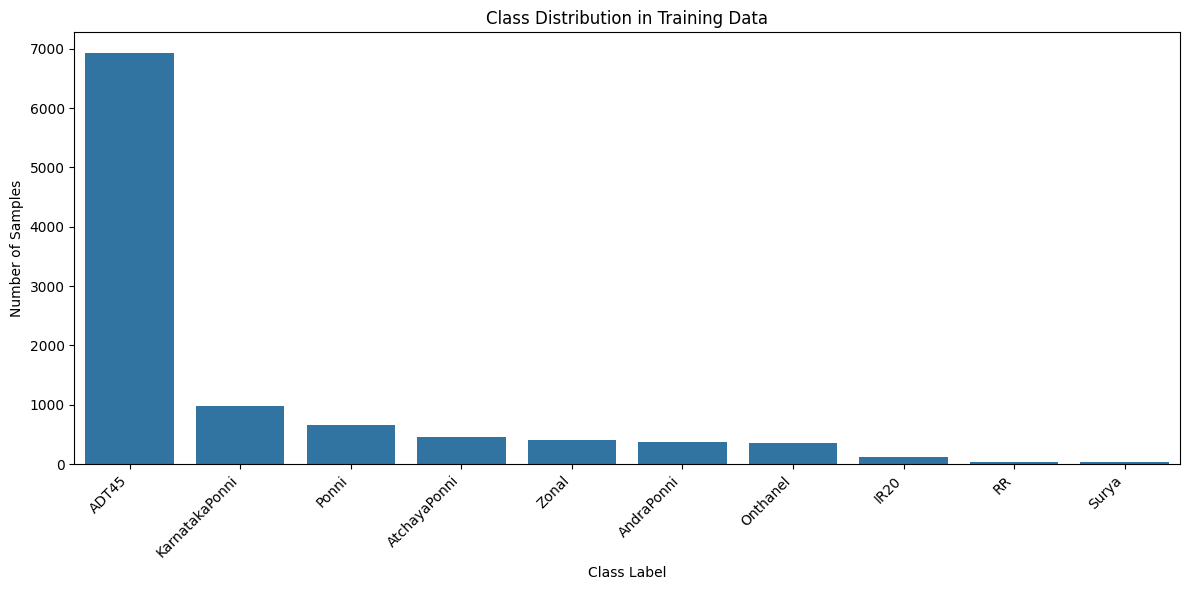

Class distribution:
ADT45: 6930 samples (67.07%)
KarnatakaPonni: 982 samples (9.50%)
Ponni: 656 samples (6.35%)
AtchayaPonni: 460 samples (4.45%)
Zonal: 399 samples (3.86%)
AndraPonni: 376 samples (3.64%)
Onthanel: 349 samples (3.38%)
IR20: 113 samples (1.09%)
RR: 36 samples (0.35%)
Surya: 32 samples (0.31%)


In [12]:
# Visualize class distribution
plt.figure(figsize=(12, 6))
class_counts = train_df['variety'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print the exact counts
print("Class distribution:")
for variety, count in class_counts.items():
    print(f"{variety}: {count} samples ({count/len(train_df)*100:.2f}%)")

In [13]:
def check_total_images(data_dir):
    """
    Prints the number of images per class and the total in the dataset directory.
    """
    total = 0
    print("Image Count Per Class:")
    print("-" * 30)
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        total += count
        print(f"{class_name:25}: {count} images")
    print("-" * 30)
    print(f"Total images in dataset: {total}")

check_total_images('dataset/train_images_by_variety/')

Image Count Per Class:
------------------------------
ADT45                    : 6930 images
AndraPonni               : 376 images
AtchayaPonni             : 460 images
IR20                     : 113 images
KarnatakaPonni           : 982 images
Onthanel                 : 349 images
Ponni                    : 656 images
RR                       : 36 images
Surya                    : 32 images
Zonal                    : 399 images
------------------------------
Total images in dataset: 10333


## New Test Data Augmentating

In [14]:
# latent_dim = 100
# image_height, image_width, image_channels = 32, 32, 3

# def make_generator():
#     model = tf.keras.Sequential([
#         layers.Dense(4*4*512, input_shape=(latent_dim,)),
#         layers.Reshape((4, 4, 512)),
#         layers.BatchNormalization(),
#         layers.LeakyReLU(),

#         layers.Conv2DTranspose(256, 4, strides=2, padding='same'),
#         layers.BatchNormalization(),
#         layers.LeakyReLU(),  # 8x8x256

#         layers.Conv2DTranspose(128, 4, strides=2, padding='same'),
#         layers.BatchNormalization(),
#         layers.LeakyReLU(),  # 16x16x128

#         layers.Conv2DTranspose(64, 4, strides=2, padding='same'),
#         layers.BatchNormalization(),
#         layers.LeakyReLU(),  # 32x32x64

#         layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh')  # 💥 64x64x3
#     ])
#     return model

# def make_discriminator():
#     model = tf.keras.Sequential([
#         layers.Conv2D(64, 4, strides=2, padding='same', input_shape=(64, 64, 3)),
#         layers.LeakyReLU(),
#         layers.Dropout(0.3),

#         layers.Conv2D(128, 4, strides=2, padding='same'),
#         layers.LeakyReLU(),
#         layers.Dropout(0.3),

#         layers.Conv2D(256, 4, strides=2, padding='same'),
#         layers.LeakyReLU(),
#         layers.Dropout(0.3),

#         layers.Flatten(),
#         layers.Dense(1, activation='sigmoid')
#     ])
#     return model
    
# loss_fn = tf.keras.losses.BinaryCrossentropy()
# gen_opt = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)
# disc_opt = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

In [15]:
# def train_gan(dataset, epochs=50):
#     generator = make_generator()
#     discriminator = make_discriminator()

#     # Move these INSIDE so they reset for each new GAN
#     gen_opt = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)
#     disc_opt = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)

#     # Define training step inside this function to access the fresh optimizers
#     @tf.function
#     def train_step(images):
#         noise = tf.random.normal([tf.shape(images)[0], latent_dim])
#         with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
#             fake_images = generator(noise, training=True)
#             real_out = discriminator(images, training=True)
#             fake_out = discriminator(fake_images, training=True)

#             gen_loss = tf.keras.losses.binary_crossentropy(tf.ones_like(fake_out), fake_out)
#             disc_loss = (
#                 tf.keras.losses.binary_crossentropy(tf.ones_like(real_out), real_out) +
#                 tf.keras.losses.binary_crossentropy(tf.zeros_like(fake_out), fake_out)
#             )

#         gen_grad = gen_tape.gradient(gen_loss, generator.trainable_variables)
#         disc_grad = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
#         gen_opt.apply_gradients(zip(gen_grad, generator.trainable_variables))
#         disc_opt.apply_gradients(zip(disc_grad, discriminator.trainable_variables))

#     for epoch in range(epochs):
#         for batch in dataset:
#             train_step(batch)

#     return generator

# def load_images_for_gan(class_path, target_shape=(64, 64)):
#     images = []
#     for fname in os.listdir(class_path):
#         if not fname.lower().endswith('.jpg'):
#             continue
#         img = Image.open(os.path.join(class_path, fname)).resize(target_shape)
#         img_array = np.array(img)
#         if img_array.shape != (64, 64, 3):
#             continue
#         images.append(img_array)
#     images = np.array(images).astype('float32')
#     images = (images - 127.5) / 127.5  # Normalize to [-1, 1]
#     return images

# def augment_with_gan(class_name, num_to_generate, class_folder):
#     print(f"[GAN] Generating {num_to_generate} images for '{class_name}'")
#     images = load_images_for_gan(class_folder)

#     if len(images) < 10:
#         print(f"Not enough images to train GAN for '{class_name}'. Skipping.")
#         return

#     dataset = tf.data.Dataset.from_tensor_slices(images).shuffle(500).batch(32)
#     generator = train_gan(dataset)

#     noise = tf.random.normal([num_to_generate, latent_dim])
#     synthetic_imgs = generator(noise, training=False)
#     synthetic_imgs = ((synthetic_imgs + 1) * 127.5).numpy().astype('uint8')

#     for i, img_array in enumerate(synthetic_imgs):
#         img = Image.fromarray(img_array)
#         img.save(os.path.join(class_folder, f'gan_{i}.jpg'))


In [16]:
# train_data_path = 'dataset/train_images_by_variety/'
# underrepresented = ['Surya', 'RR', 'IR20', 'Onthanel', 'AndraPonni', 'Zonal']

# # Count current images per class
# class_counts = {}
# for class_name in os.listdir(train_data_path):
#     class_path = os.path.join(train_data_path, class_name)
#     if not os.path.isdir(class_path): continue
#     images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
#     class_counts[class_name] = len(images)

# average_count = int(np.mean(list(class_counts.values())))
# print(f"Target image count per class: {average_count}")

# # Apply GAN augmentation
# for class_name in underrepresented:
#     if class_name not in class_counts:
#         continue
#     current = class_counts[class_name]
#     needed = average_count - current
#     if needed > 0:
#         class_path = os.path.join(train_data_path, class_name)
#         augment_with_gan(class_name, needed, class_path)


## Augmentating the Data before Splitting and Loading

In [17]:
train_data_path = 'dataset/train_images_by_variety/'

# Step 1: Count images per class
class_counts = {}
for class_name in os.listdir(train_data_path):
    class_path = os.path.join(train_data_path, class_name)
    if not os.path.isdir(class_path): continue
    image_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    class_counts[class_name] = len(image_files)

# Step 2: Define augmentation
augmentor = ImageDataGenerator(
    rotation_range=30,               # More rotation
    shear_range=0.3,                 # Stronger shearing
    zoom_range=[0.6, 1.4],           # Bigger zoom range (zoom in & out)
    width_shift_range=0.3,
    height_shift_range=0.3,
    brightness_range=(0.4, 1.6),     # Drastic brightness changes
    channel_shift_range=30.0,        # Deep color shifts
    horizontal_flip=True,
    vertical_flip=True,              # Enable if orientation doesn't matter
    fill_mode='nearest'
)

average_count = int(np.mean(list(class_counts.values())))
print(f"Target image count per class: {average_count}")

# Step 3: Augment classes below the average
for class_name, count in class_counts.items():
    if count >= average_count:
        print(f"Skipping '{class_name}' (already has {count} images)")
        continue

    class_path = os.path.join(train_data_path, class_name)
    images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    current_count = count
    augment_index = 0

    print(f"Augmenting '{class_name}' from {current_count} to {average_count}")
    pbar = tqdm(total=average_count - current_count)

    while current_count < average_count:
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            img = load_img(img_path)
            x = img_to_array(img).reshape((1,) + img_to_array(img).shape)

            batch = next(augmentor.flow(x, batch_size=1))
            new_img = array_to_img(batch[0])
            new_img.save(os.path.join(class_path, f'aug_{augment_index}.jpg'))

            current_count += 1
            augment_index += 1
            pbar.update(1)

            if current_count >= average_count:
                break

    pbar.close()


Target image count per class: 1033
Skipping 'ADT45' (already has 6930 images)
Augmenting 'AndraPonni' from 376 to 1033


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 657/657 [00:41<00:00, 15.99it/s]


Augmenting 'AtchayaPonni' from 460 to 1033


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 573/573 [00:36<00:00, 15.91it/s]


Augmenting 'IR20' from 113 to 1033


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 997/997 [00:54<00:00, 18.31it/s]


Augmenting 'Surya' from 32 to 1033


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:55<00:00, 18.03it/s]


Augmenting 'Zonal' from 399 to 1033


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 634/634 [00:39<00:00, 15.96it/s]


### Data Normalization and Data Generator

In [18]:
check_total_images('dataset/train_images_by_variety/')

Image Count Per Class:
------------------------------
ADT45                    : 6930 images
AndraPonni               : 1033 images
AtchayaPonni             : 1033 images
IR20                     : 1033 images
KarnatakaPonni           : 1033 images
Onthanel                 : 1033 images
Ponni                    : 1033 images
RR                       : 1033 images
Surya                    : 1033 images
Zonal                    : 1033 images
------------------------------
Total images in dataset: 16227


In [19]:
BATCH_SIZE = 32
IMAGE_SHAPE = (224,224)
train_data_path = 'dataset/train_images_by_variety/'

# For training data - with augmentation
data_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80/20 split
)

With these parameters as data augmentation parameters, I split the dataset with the reatio of 0.8-0.2.

In [20]:
# For training data (with augmentation)
train_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='training',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 12987 images belonging to 10 classes.


In [21]:
# For validation data (without augmentation)
valid_gen = data_gen.flow_from_directory(
    train_data_path,
    target_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    subset='validation',
    seed=42,
    class_mode='categorical',
    color_mode='rgb'
)

Found 3240 images belonging to 10 classes.


## Data Distribution After Augmentated

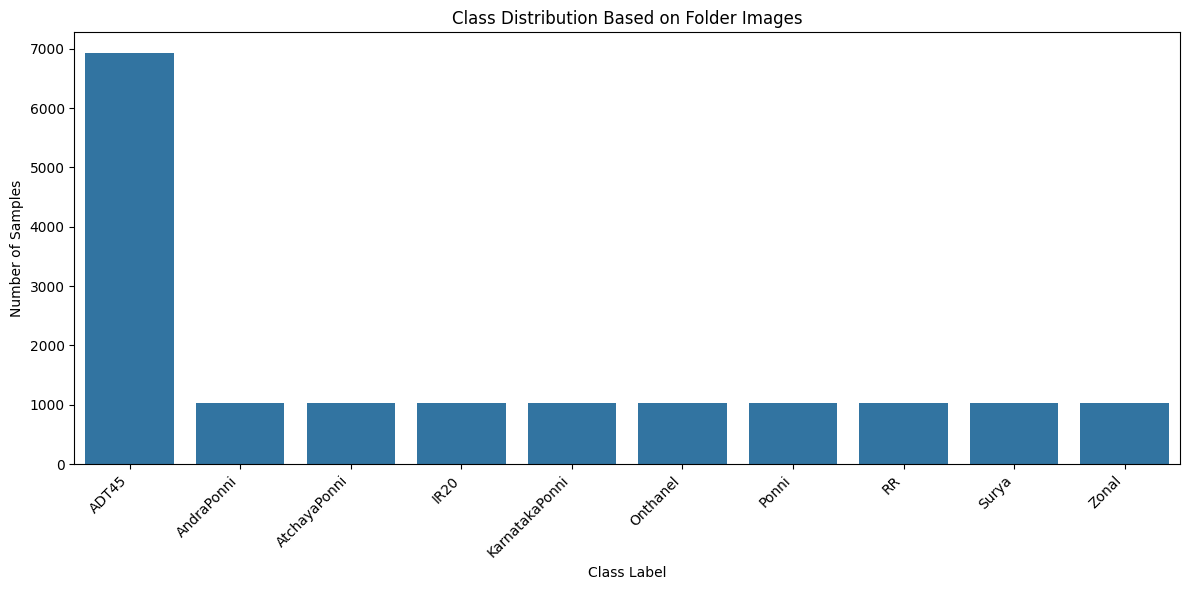

Updated Class Distribution:
ADT45: 6930 samples (42.71%)
AndraPonni: 1033 samples (6.37%)
AtchayaPonni: 1033 samples (6.37%)
IR20: 1033 samples (6.37%)
KarnatakaPonni: 1033 samples (6.37%)
Onthanel: 1033 samples (6.37%)
Ponni: 1033 samples (6.37%)
RR: 1033 samples (6.37%)
Surya: 1033 samples (6.37%)
Zonal: 1033 samples (6.37%)


In [22]:
from collections import Counter

folder_counts = {}
for class_name in os.listdir(train_data_path):
    class_folder = os.path.join(train_data_path, class_name)
    if os.path.isdir(class_folder):
        count = len([f for f in os.listdir(class_folder) if f.endswith('.jpg')])
        folder_counts[class_name] = count

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(folder_counts.keys()), y=list(folder_counts.values()))
plt.title('Class Distribution Based on Folder Images')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print counts
print("Updated Class Distribution:")
total_imgs = sum(folder_counts.values())
for label, count in folder_counts.items():
    print(f"{label}: {count} samples ({(count/total_imgs)*100:.2f}%)")


### Data Class Weighting

Calculate class weighting on the dataframe

In [23]:
def get_class_counts_from_folders(data_dir):
    """
    Returns a dictionary with image counts per class folder.
    """
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        count = len([f for f in os.listdir(class_path) if f.endswith('.jpg')])
        class_counts[class_name] = count
    return class_counts

def calculate_class_weights(class_counts):
    """
    Calculates class weights inversely proportional to class frequencies.
    """
    total_samples = sum(class_counts.values())
    num_classes = len(class_counts)
    class_weights = {}

    for class_name, count in class_counts.items():
        class_weights[class_name] = total_samples / (num_classes * count)

    print("Class weights:")
    for class_name, weight in class_weights.items():
        print(f"Class '{class_name}': {weight:.4f}")

    return class_weights

def map_weights_to_generator_indices(class_weights, generator_class_indices):
    """
    Maps class weights (based on class names) to generator indices used during model training.
    """
    index_weights = {}

    for class_name, weight in class_weights.items():
        if class_name in generator_class_indices:
            index = generator_class_indices[class_name]
            index_weights[index] = weight
        else:
            print(f"Warning: Class '{class_name}' not found in generator indices")

    for class_name, index in generator_class_indices.items():
        if index not in index_weights:
            print(f"Warning: No weight assigned for generator class '{class_name}' (index {index})")

    return index_weights


In [24]:
# Step 1: Get counts directly from folders
class_counts = get_class_counts_from_folders(train_data_path)

# Step 2: Compute weights
class_weights = calculate_class_weights(class_counts)

# Step 3: Get generator class indices
generator_class_indices = train_gen.class_indices
print("Generator class indices:", generator_class_indices)

# Step 4: Map weights to generator indices
index_weights = map_weights_to_generator_indices(class_weights, generator_class_indices)

print("-" * 30)

# Final weights to use in model.fit()
print("Mapped index weights:")
for idx, weight in sorted(index_weights.items()):
    print(f"Index {idx}: {weight:.4f}")

Class weights:
Class 'ADT45': 0.2342
Class 'AndraPonni': 1.5709
Class 'AtchayaPonni': 1.5709
Class 'IR20': 1.5709
Class 'KarnatakaPonni': 1.5709
Class 'Onthanel': 1.5709
Class 'Ponni': 1.5709
Class 'RR': 1.5709
Class 'Surya': 1.5709
Class 'Zonal': 1.5709
Generator class indices: {'ADT45': 0, 'AndraPonni': 1, 'AtchayaPonni': 2, 'IR20': 3, 'KarnatakaPonni': 4, 'Onthanel': 5, 'Ponni': 6, 'RR': 7, 'Surya': 8, 'Zonal': 9}
------------------------------
Mapped index weights:
Index 0: 0.2342
Index 1: 1.5709
Index 2: 1.5709
Index 3: 1.5709
Index 4: 1.5709
Index 5: 1.5709
Index 6: 1.5709
Index 7: 1.5709
Index 8: 1.5709
Index 9: 1.5709


## Callback functions for training monitoring and improvement

In [25]:
# Callbacks for monitoring NaN Values
class TerminateNaN(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        loss = logs.get('loss')
        if loss is not None:
            if np.isnan(loss) or np.isinf(loss):
                print(f"Invalid loss and terminated at loss {loss}; epoch: {epoch}")
                self.model.stop_training = True

terminate_nan = TerminateNaN()

# Callbacks for checking loss spike
class LossSpikeStopper(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get('val_loss')
        if val_loss is not None and val_loss > 5.0 and epoch > 10:
            print(f"\n[Early Stop] Validation loss spiked to {val_loss:.4f} at epoch {epoch}.")
            self.model.stop_training = True

loss_spike_stopper = LossSpikeStopper()

In [26]:
# Save model after every epoch if the validation accuracy improves from previous epoch
cnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task2_cnn_model.h5',
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

In [27]:
efficient_net_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task2_efficient_net_model.h5',
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

In [28]:
resnet50_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='saved_model/task2_resnet50_model.h5',
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode='auto',
    save_weights_only=False,
    save_freq='epoch'
)

In [29]:
# Standard learning rate reduction on plateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=3,
    verbose=1,
    mode="auto",
    min_delta=0.001,
    cooldown=1,
    min_lr=1e-6
)

# Early stopping to prevent overfitting (validation loss stops improving)
early_stopping_loss = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

# Early stopping if validation accuracy doesn't improve
early_stopping_accuracy = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    min_delta=0.001,
    patience=10,
    verbose=1,
    mode='max',
    restore_best_weights=True
)


# CSV logger to save training metrics to file
cnn_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task2_cnn_training_history.csv',
    separator=',',
    append=True
)

efficient_net_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task2_efficient_net_training_history.csv',
    separator=',',
    append=True
)

resnet50_csv_logger = tf.keras.callbacks.CSVLogger(
    filename='logs/task2_resnet50_training_history.csv',
    separator=',',
    append=True
)

# Tensorboard test Track metrics, images, and more with TensorBoard:
tensorboard_cb = TensorBoard(log_dir='logs', histogram_freq=1)

## Evaluation Model

In [30]:
def evaluate_model(history):
    plt.figure(figsize=(18, 5))

    # Accuracy plot
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Precision plot
    plt.subplot(1, 3, 2)
    plt.plot(history.history['precision'], label='Train Precision')
    if 'val_precision' in history.history:
        plt.plot(history.history['val_precision'], label='Val Precision')
    plt.title('Model Precision')
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.legend()

    # Loss plot
    plt.subplot(1, 3, 3)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

### CNN Model

In [31]:
# For Task 2: Paddy Variety Identification with in-model augmentation
num_classes = 10
l2_reg = 1e-4  # L2 regularization strength
dropout_rate = 0.3  # You can adjust this (e.g., 0.3 to 0.5)

cnn_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(l2_reg), input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(dropout_rate),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(dropout_rate),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(dropout_rate),

    # Flatten & Dense
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # Slightly higher dropout before output

    # Output
    layers.Dense(num_classes, activation='softmax',kernel_regularizer=regularizers.l2(l2_reg))
])

# Compile the model
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")]
)

cnn_model.build(input_shape=(None, 224, 224, 3))
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 112, 112, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 112, 112, 64)     2

In [32]:
cnn_history = cnn_model.fit(
    train_gen,
    batch_size = 16,
    validation_data = valid_gen,
    epochs=150,
    verbose=1,
    class_weight=index_weights,
        callbacks = [
            early_stopping_loss,
            early_stopping_accuracy,
            reduce_lr,
            loss_spike_stopper,
            terminate_nan,
            cnn_checkpoint,
            cnn_csv_logger,
            tensorboard_cb,
        ]
)

Epoch 1/150
406/406 [==============================] - ETA: 0s - loss: 2.1971 - accuracy: 0.3588 - precision: 0.4632 - recall: 0.2040  
Epoch 1: val_accuracy improved from -inf to 0.06728, saving model to saved_model\task2_cnn_model.h5
406/406 [==============================] - 167s 397ms/step - loss: 2.1971 - accuracy: 0.3588 - precision: 0.4632 - recall: 0.2040 - val_loss: 48.8210 - val_accuracy: 0.0673 - val_precision: 0.0673 - val_recall: 0.0673 - lr: 1.0000e-04
Epoch 2/150
406/406 [==============================] - ETA: 0s - loss: 1.6565 - accuracy: 0.4987 - precision: 0.6144 - recall: 0.3449  
Epoch 2: val_accuracy improved from 0.06728 to 0.48302, saving model to saved_model\task2_cnn_model.h5
406/406 [==============================] - 43s 106ms/step - loss: 1.6565 - accuracy: 0.4987 - precision: 0.6144 - recall: 0.3449 - val_loss: 3.0753 - val_accuracy: 0.4830 - val_precision: 0.5002 - val_recall: 0.4309 - lr: 1.0000e-04
Epoch 3/150
406/406 [==============================] - ET

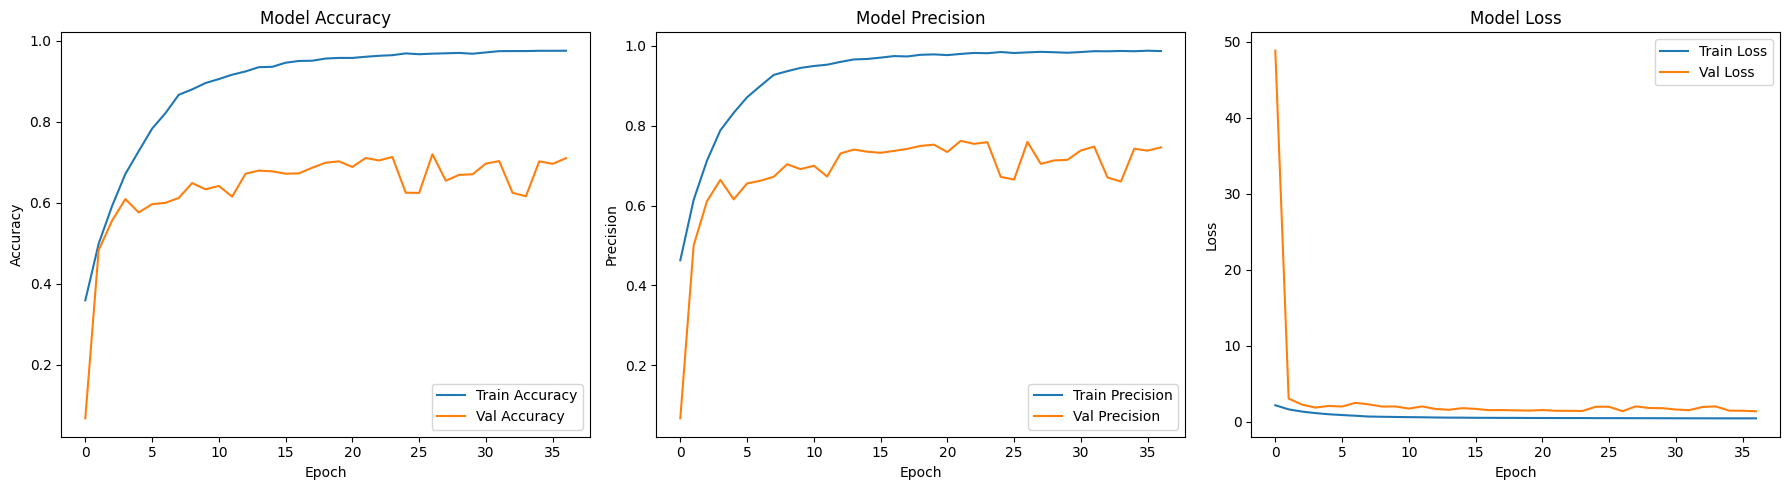

In [33]:
cnn_val_acc = evaluate_model(cnn_history)

### EfficientNet Model

In [34]:
from tensorflow.keras import layers, models, regularizers
import tensorflow as tf

# Configuration
input_shape = (224, 224, 3)  # You can also use 300x300 (default for B3)
num_classes = 10
l2_reg = 1e-4

# Load EfficientNetB3 without pretrained weights
base_model = EfficientNetB0(
    include_top=False,
    weights=None,  # Training from scratch
    input_shape=input_shape
)

# Make the base model trainable
base_model.trainable = True

# Custom classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

# Final model
efficientnet_model = models.Model(inputs=base_model.input, outputs=outputs)

# Compile the model
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Print summary
efficientnet_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 stem_conv_pad (ZeroPadding2D)  (None, 225, 225, 3)  0           ['normalization[0][0]']      

In [35]:
efficient_net_history = efficientnet_model.fit(
    train_gen,
    batch_size = 16,
    validation_data = valid_gen,
    epochs=150,
    verbose=1,
    class_weight=index_weights,
        callbacks = [
            early_stopping_loss,
            early_stopping_accuracy,
            reduce_lr,
            loss_spike_stopper,
            terminate_nan,
            efficient_net_checkpoint,
            efficient_net_csv_logger,
            tensorboard_cb,
        ]
)

Epoch 1/150
406/406 [==============================] - ETA: 0s - loss: 2.9258 - accuracy: 0.1241 - precision: 0.1314 - recall: 0.0221  
Epoch 1: val_accuracy improved from -inf to 0.06358, saving model to saved_model\task2_efficient_net_model.h5
406/406 [==============================] - 86s 199ms/step - loss: 2.9258 - accuracy: 0.1241 - precision: 0.1314 - recall: 0.0221 - val_loss: 2.5992 - val_accuracy: 0.0636 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/150
406/406 [==============================] - ETA: 0s - loss: 2.6424 - accuracy: 0.1678 - precision: 0.2198 - recall: 0.0332  
Epoch 2: val_accuracy improved from 0.06358 to 0.17840, saving model to saved_model\task2_efficient_net_model.h5
406/406 [==============================] - 80s 196ms/step - loss: 2.6424 - accuracy: 0.1678 - precision: 0.2198 - recall: 0.0332 - val_loss: 2.3074 - val_accuracy: 0.1784 - val_precision: 0.3276 - val_recall: 0.0296 - lr: 1.0000e-04
Epoch 3/150
406/406 [==========

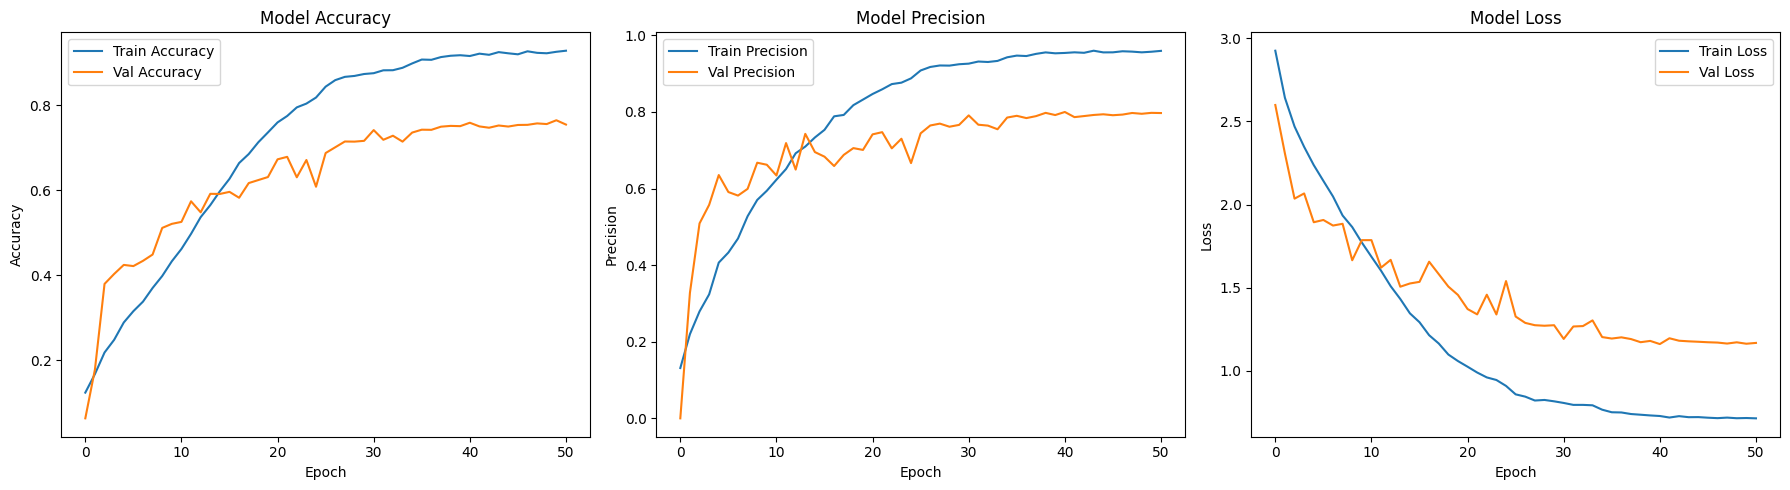

In [36]:
efficient_net_val_acc = evaluate_model(efficient_net_history)

### ResNet Model

In [37]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Model, layers, Input, regularizers

num_classes = 10
l2_reg = 1e-4

# Base ResNet50 (from scratch)
base_model = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

# Input Layer
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs)
x = layers.GlobalAveragePooling2D()(x)

# Feature Extractor
features = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
features = layers.BatchNormalization()(features)
features = layers.Dropout(0.5)(features)

# Attention Mechanism
attention_weights = layers.Dense(512, activation='sigmoid', name='attention_weights')(features)
attention_output = layers.Multiply()([features, attention_weights])

# Classification Head
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(attention_output)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Output Layer
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Build the Model
resnet50_model = Model(inputs=inputs, outputs=outputs)

# Compile the Model
resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# Show Summary
resnet50_model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 resnet50 (Functional)          (None, 7, 7, 2048)   23587712    ['input_3[0][0]']                
                                                                                                  
 global_average_pooling2d_1 (Gl  (None, 2048)        0           ['resnet50[0][0]']               
 obalAveragePooling2D)                                                                            
                                                                                            

In [38]:
resnet50_history = resnet50_model.fit(
    train_gen,
    batch_size=16,
    validation_data=valid_gen,
    epochs=150,
    verbose=1,
    class_weight=index_weights,
    callbacks=[
        early_stopping_loss,
        early_stopping_accuracy,
        reduce_lr,
        loss_spike_stopper,
        terminate_nan,
        resnet50_checkpoint,
        resnet50_csv_logger
    ]
)

Epoch 1/150
406/406 [==============================] - ETA: 0s - loss: 3.0249 - accuracy: 0.1390 - precision: 0.1628 - recall: 0.0436  
Epoch 1: val_accuracy improved from -inf to 0.06728, saving model to saved_model\task2_resnet50_model.h5
406/406 [==============================] - 105s 247ms/step - loss: 3.0249 - accuracy: 0.1390 - precision: 0.1628 - recall: 0.0436 - val_loss: 5.1821 - val_accuracy: 0.0673 - val_precision: 0.0635 - val_recall: 0.0630 - lr: 1.0000e-04
Epoch 2/150
406/406 [==============================] - ETA: 0s - loss: 2.6705 - accuracy: 0.2061 - precision: 0.2598 - recall: 0.0732  
Epoch 2: val_accuracy improved from 0.06728 to 0.34444, saving model to saved_model\task2_resnet50_model.h5
406/406 [==============================] - 98s 242ms/step - loss: 2.6705 - accuracy: 0.2061 - precision: 0.2598 - recall: 0.0732 - val_loss: 2.3770 - val_accuracy: 0.3444 - val_precision: 0.5908 - val_recall: 0.1315 - lr: 1.0000e-04
Epoch 3/150
406/406 [===========================

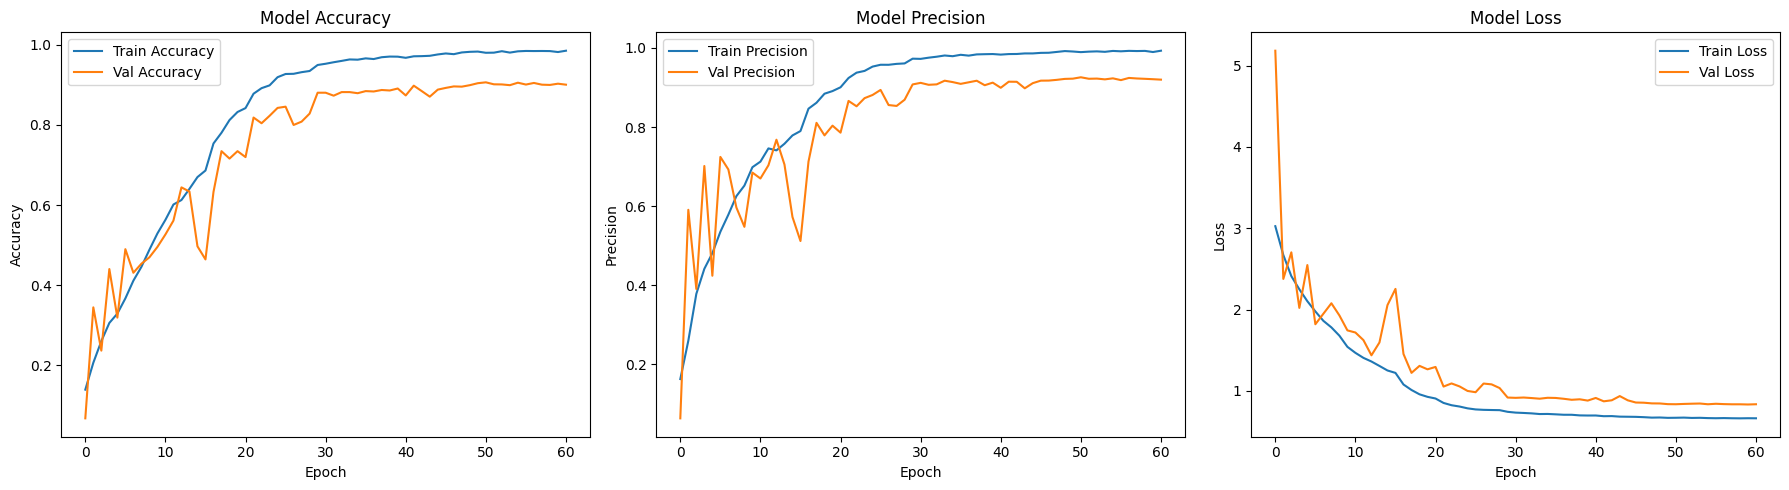

In [39]:
resnet_val_acc = evaluate_model(resnet50_history)

Check best model

In [40]:
histories = {
    "CNN": cnn_history,
    "EfficientNet": efficient_net_history,
    "ResNet50": resnet50_history,
}

def find_best_model(histories, task_type='classification'):
    """
    histories: dict with model names as keys and History objects as values
    task_type: 'classification' or 'regression'
    """
    best_score = -float('inf') if task_type == 'classification' else float('inf')
    best_model = None

    for name, hist in histories.items():
        if task_type == 'classification':
            val_acc = max(hist.history.get('val_accuracy', [0]))  # Updated to match compile()
            print(f"{name}: Best Val Accuracy = {val_acc:.4f}")
            if val_acc > best_score:
                best_score = val_acc
                best_model = name
        elif task_type == 'regression':
            val_mae = min(hist.history.get('val_mae', [float('inf')]))
            print(f"{name}: Best Val MAE = {val_mae:.4f}")
            if val_mae < best_score:
                best_score = val_mae
                best_model = name

    print(f"\nBest model: {best_model} with {'accuracy' if task_type == 'classification' else 'MAE'} = {best_score:.4f}")
    return best_model

find_best_model(histories, 'classification')

CNN: Best Val Accuracy = 0.7201
EfficientNet: Best Val Accuracy = 0.7651
ResNet50: Best Val Accuracy = 0.9065

Best model: ResNet50 with accuracy = 0.9065


'ResNet50'

Model           | Metric                    | Best Value      | Epoch     
CNN             | val_precision             | 0.7622          | 22        
CNN             | val_loss                  | 1.4019          | 37        
CNN             | val_recall                | 0.6775          | 27        
CNN             | val_accuracy              | 0.7201          | 27        
EfficientNet    | val_precision             | 0.7999          | 41        
EfficientNet    | val_loss                  | 1.1606          | 41        
EfficientNet    | val_recall                | 0.7173          | 48        
EfficientNet    | val_accuracy              | 0.7651          | 50        
ResNet50        | val_precision             | 0.9260          | 51        
ResNet50        | val_loss                  | 0.8332          | 60        
ResNet50        | val_recall                | 0.8861          | 60        
ResNet50        | val_accuracy              | 0.9065          | 51        

BEST MODEL FOR EACH METR

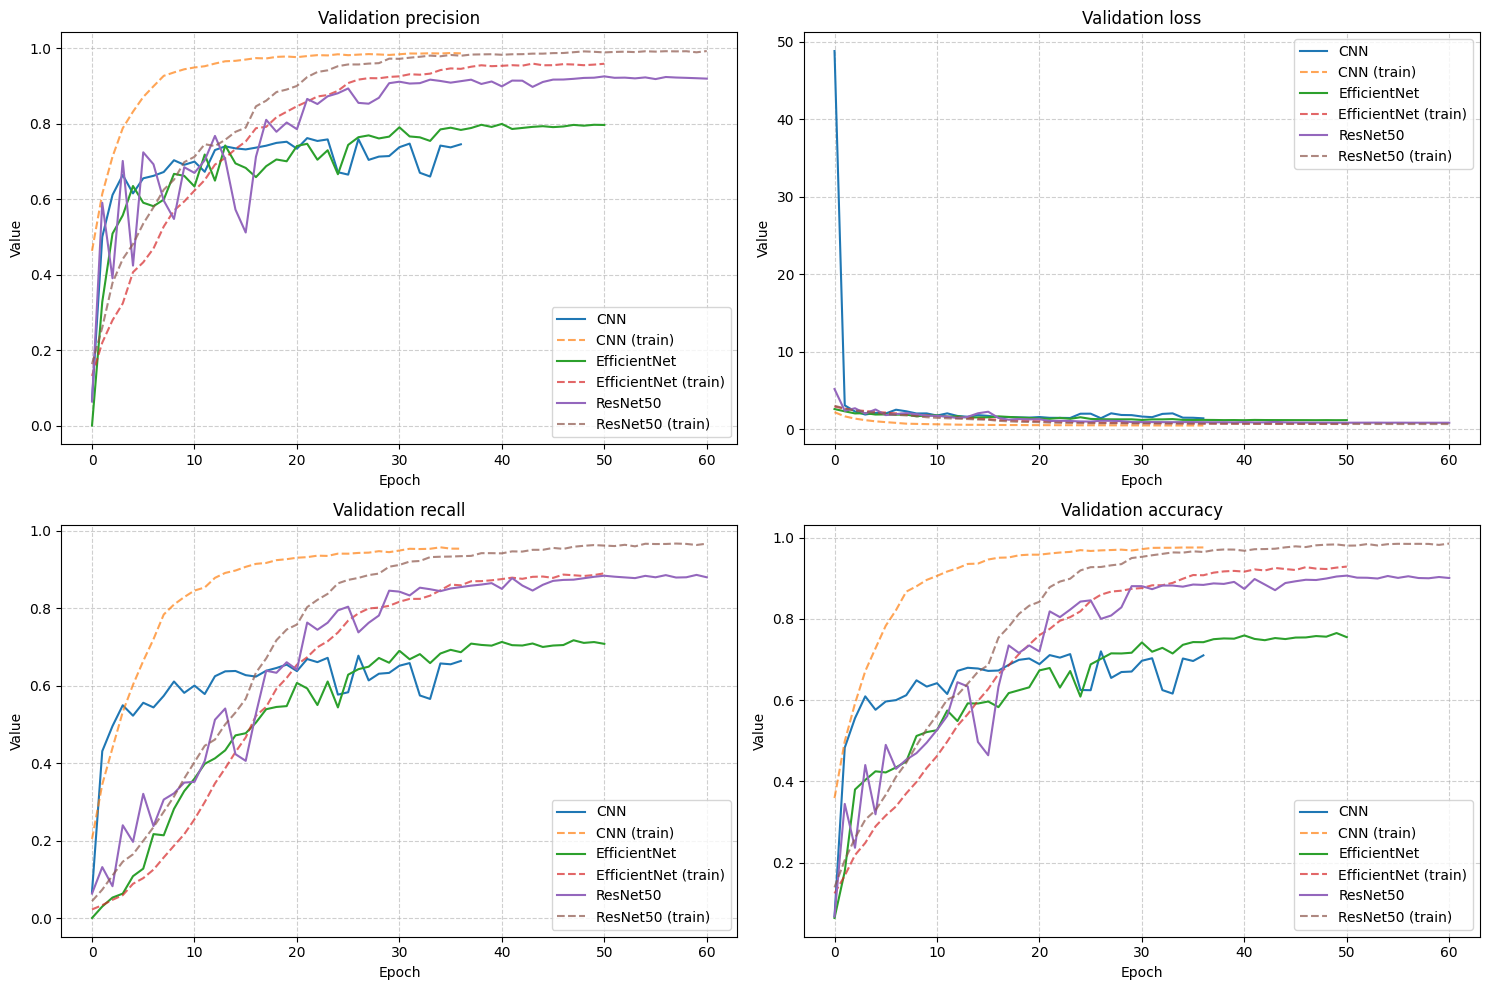

In [41]:
def evaluate_models(histories, metrics_to_check=None):
    """
    A comprehensive function to evaluate and compare multiple models based on their training histories.
    
    Parameters:
        histories: Dictionary with model names as keys and History objects as values
        metrics_to_check: List of metrics to analyze (if None, will check all available metrics)
        
    Returns:
        Dictionary with best models for different metrics
    """
    # If no specific metrics provided, collect all available metrics from histories
    if metrics_to_check is None:
        metrics_to_check = set()
        for hist in histories.values():
            for metric in hist.history.keys():
                if metric.startswith('val_'):
                    metrics_to_check.add(metric)
    
    results = {}
    summary = {}
    
    print("=" * 80)
    print(f"{'Model':<15} | {'Metric':<25} | {'Best Value':<15} | {'Epoch':<10}")
    print("=" * 80)
    
    # Process each model's history
    for model_name, history in histories.items():
        model_results = {}
        
        for metric in metrics_to_check:
            if metric in history.history:
                values = history.history[metric]
                
                is_maximize = not any(key in metric for key in ['loss', 'error', 'mae', 'mse'])
                
                if is_maximize:
                    best_value = max(values)
                    best_epoch = values.index(best_value) + 1
                else:
                    best_value = min(values)
                    best_epoch = values.index(best_value) + 1
                
                model_results[metric] = {
                    'best_value': best_value,
                    'best_epoch': best_epoch,
                    'is_maximize': is_maximize
                }
                
                value_format = f"{best_value:.4f}"
                print(f"{model_name:<15} | {metric:<25} | {value_format:<15} | {best_epoch:<10}")
                
                if metric not in summary:
                    summary[metric] = {
                        'best_model': model_name,
                        'best_value': best_value
                    }
                else:
                    current_best = summary[metric]['best_value']
                    if (is_maximize and best_value > current_best) or (not is_maximize and best_value < current_best):
                        summary[metric]['best_model'] = model_name
                        summary[metric]['best_value'] = best_value
        
        results[model_name] = model_results
    
    print("\n" + "=" * 50)
    print("BEST MODEL FOR EACH METRIC:")
    print("=" * 50)
    
    for metric, data in summary.items():
        print(f"{metric:<25}: {data['best_model']} (Value: {data['best_value']:.4f})")
    
    # Visualization of training curves
    plt.figure(figsize=(15, 10))
    
    viz_metrics = [m for m in metrics_to_check if m.startswith('val_')]
    if not viz_metrics:
        viz_metrics = list(metrics_to_check)[:4]  # fallback
    
    for i, metric in enumerate(viz_metrics[:4]):  # Max 4 plots
        plt.subplot(2, 2, i + 1)
        
        for model_name, history in histories.items():
            if metric in history.history:
                plt.plot(history.history[metric], label=f"{model_name}")
                
                train_metric = metric.replace('val_', '')
                if train_metric in history.history:
                    plt.plot(history.history[train_metric], linestyle='--',
                             alpha=0.7, label=f"{model_name} (train)")
        
        plt.title(metric.replace("val_", "Validation ").capitalize())
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return summary

best_models = evaluate_models(histories)